In [19]:
#載入套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [20]:
#使用資料夾內鐵達尼號的資料集，練習邏輯迴歸的處理邏輯
train = pd.read_csv('data/titanic_data.csv')
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


<Axes: >

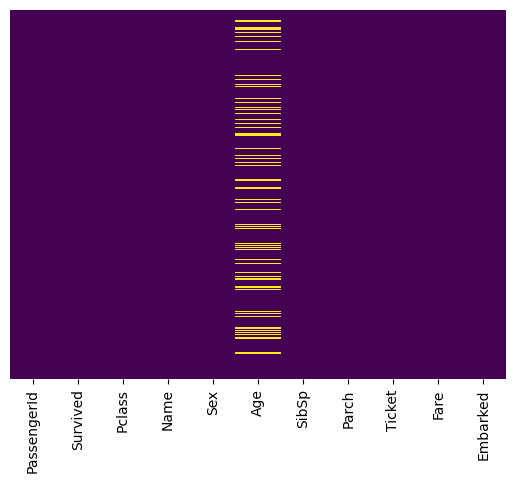

In [21]:
#探索資料
#用heatmap(.isnull()來找出缺失的資料在哪些欄位。Age似乎約有五分之一的資料缺失，可用合理資料補充。)
#用 Seaborn 的 Heatmap（熱力圖）來視覺化資料中的缺失值（Missing Values / NaN）
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')
#train.isnull()檢查每個儲存格是否為缺失值（NaN）
#True表示這個位置有缺失值 NaN；False代表資料存在
#sns.heatmap()，將 True / False 畫成顏色
#yticklables=False, 隱藏 Y 軸標籤，不顯示列號，畫面較乾淨
#cbar=False，隱藏 Color Bar（顏色對照條），只想看到是否有缺失值，不需要刻度
#cmap='viridis'，指定色彩風格（Color Map），使用Viridis配色，深紫-->藍-->綠-->黃
#在機器學習前必做資料探索（EDA），許多模型:Logistic Regression、SVM、KNN、Neural Network，都不能直接處理 NaN；所以可先用Heatmap()看是否有缺值

<Axes: xlabel='Survived', ylabel='count'>

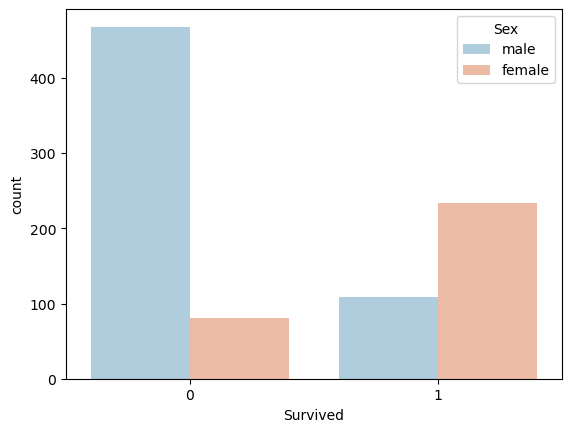

In [22]:
#用countplot來看性別是否影響最後存活。女性存活比例比男性高。
#countplot() 是 Seaborn 套件用來統計類別資料數量並繪製長條圖（Bar Chart)的函式
sns.countplot(x='Survived',hue='Sex',data=train,palette='RdBu_r')
#以Titanic資料集的 Survived 欄位作為 X 軸，再依照性別分組顯示；data=train指定資料來源；設定顏色主題，Rd=Red、Bu=Blue、_r=reverse(反轉)，會使用紅藍配色
#0死亡、1存活

<Axes: xlabel='Survived', ylabel='count'>

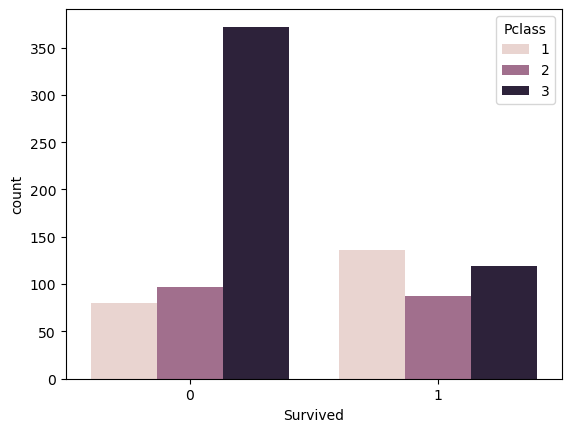

In [13]:
#艙等是否也影響存活?
sns.countplot(x='Survived',hue='Pclass',data=train)

C:\Users\pingy\AppData\Local\Temp\ipykernel_30648\2190167306.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False,bins=30)


<Axes: xlabel='Age'>

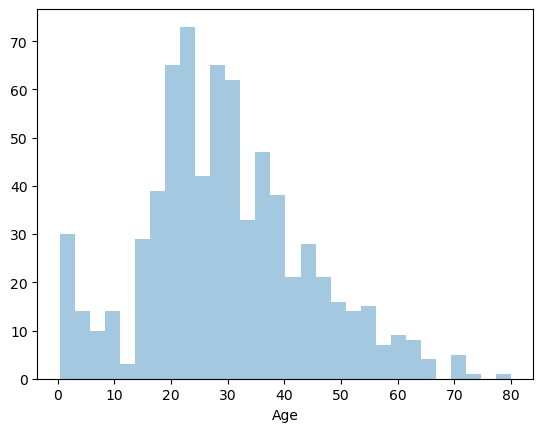

In [14]:
#用直方圖看年齡分佈。缺失資料在此不計。
sns.distplot(train['Age'].dropna(),kde=False,bins=30)
#train['Age']：取得Titanic資料集中的Age欄位；.dropna()：移除缺失值（NaN）；
#sns.distplot()，繪製資料分布圖，預設會畫Histogram（直方圖）

C:\Users\pingy\AppData\Local\Temp\ipykernel_30648\401940927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp',data=train,palette='Set1')


<Axes: xlabel='SibSp', ylabel='count'>

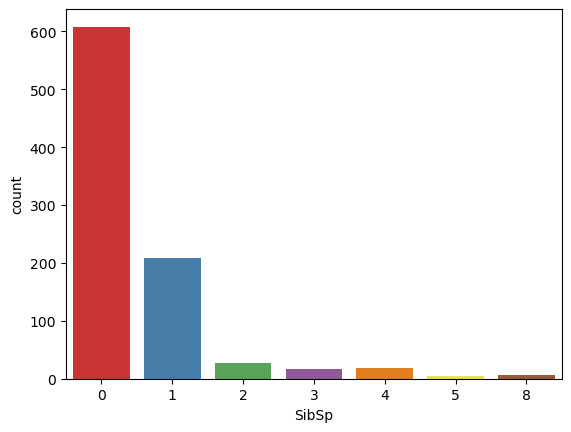

In [25]:
#SibSp代表兄弟姐妹或眷屬人數
sns.countplot(x='SibSp',data=train,palette='Set1')

<Axes: >

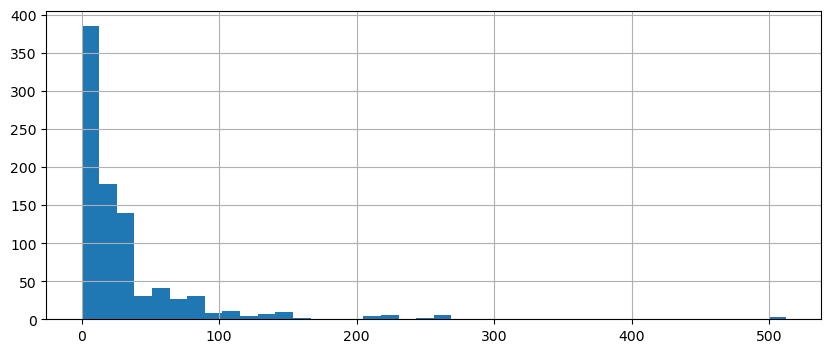

In [27]:
#用直方圖看票價分佈
#使用 Pandas 的 hist() 函式繪製 Fare（票價）欄位的直方圖（Histogram），用來觀察票價的分布情況
train['Fare'].hist(bins=40,figsize=(10,4))
#train['Fare']，取出 Titanic 資料集中的 Fare 欄位；.hist()，Histogram（直方圖）；bins=40表示將資料切成40個區間；figsize(10,4)，設定圖表大小，寬10、高4

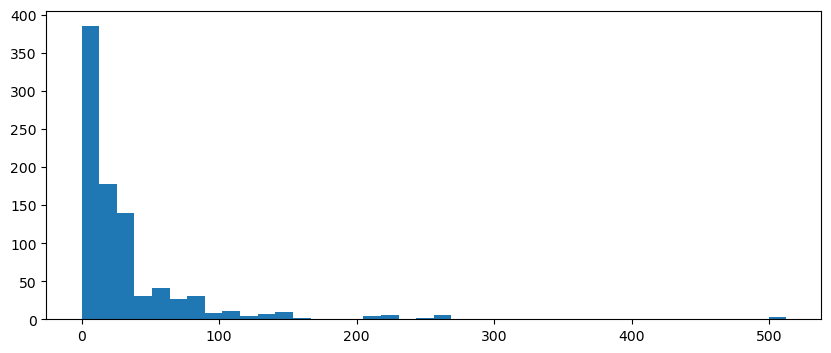

In [16]:
#使用 Matplotlib
plt.figure(figsize=(10,4))
plt.hist(train['Fare'], bins=40)
plt.show()

<Axes: xlabel='Fare', ylabel='Count'>

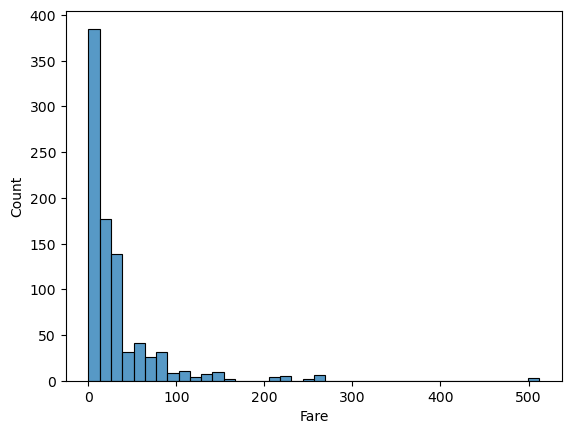

In [17]:
#使用 Seaborn
sns.histplot(train['Fare'],bins=40)

C:\Users\pingy\AppData\Local\Temp\ipykernel_30648\3450504570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=train,palette=['blue', 'orange', 'green'])


<Axes: xlabel='Pclass', ylabel='Age'>

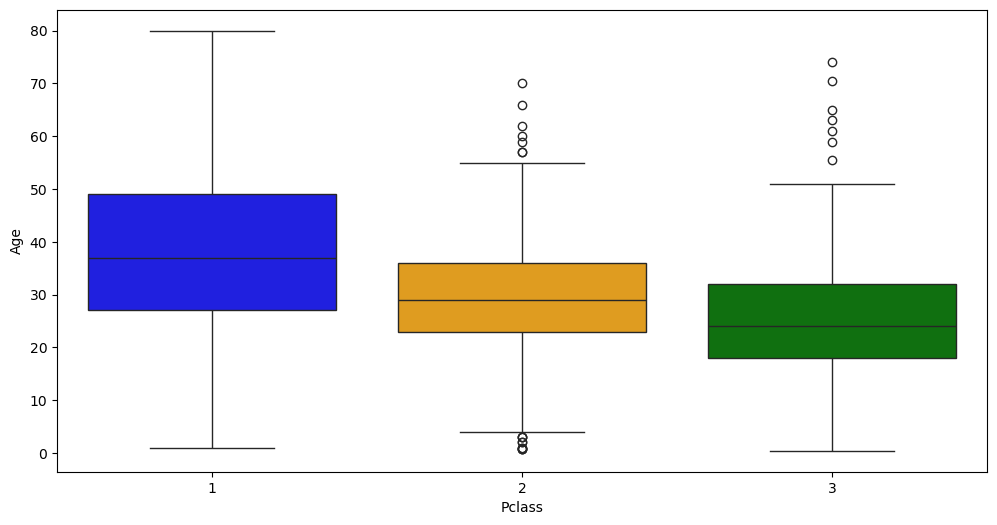

In [29]:
#資料清理
#剛有看到年齡資料約有五分之一缺失，一種做法是棄之不用，一種可以考慮把年齡平均放進去。
#使用盒鬚圖來看年齡和艙等的分佈。看起來頭等艙年齡較高，隨之降低。
plt.figure(figsize=(12,6))
sns.boxplot(x='Pclass',y='Age',data=train,palette=['blue', 'orange', 'green'])
#Boxplot(盒鬚圖、箱型圖）是資料分析中非常重要的圖表，用來：快速了解資料的分布、集中趨勢、離群值（Outliers）以及資料是否偏態
#Boxplot()五大資訊：1.最小值 (Minimum)_下鬚線最底端;2.第一四分位數 Q1_盒子底部25%位置；3.中位數Median_盒子中間那條線;4.第三四分位數Q3_盒子頂部75%位置；5.最大值 Maximum_上鬚線最頂端
#Boxplot最重要的概念：四分位距IQR=Q3−Q1
#oooo代表離群值

In [30]:
#把艙等平均年齡填入缺失的資料中
#艙等1平均年齡是37，艙等2平均年齡是29，艙等3平均年齡是24
def impute_age(cols): #定義impute_age()函式，參數cols
    Age = cols[0] #取出age；新版Pandas建議寫成 Age = cols.iloc[0]
    Pclass = cols[1] #取出Pclass；新版Pandas建議寫成 Pclass = cols.iloc[1]
    if pd.isnull(Age): #判斷age是否為NaN，若是
        if Pclass == 1: #判斷艙等是否為1，若是
            return 37   #則補37歲
        elif Pclass == 2: #若艙等為2
            return 29 #則補29歲
        else:
            return 24 #否則剩下的補24歲
    else: #表示年齡不缺失
        return Age #則直接保留

train['Age'] = train[['Age','Pclass']].apply(impute_age,axis=1)
#.apply()的意思是對每一行執行()內

C:\Users\pingy\AppData\Local\Temp\ipykernel_30648\584182515.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\pingy\AppData\Local\Temp\ipykernel_30648\584182515.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


<Axes: >

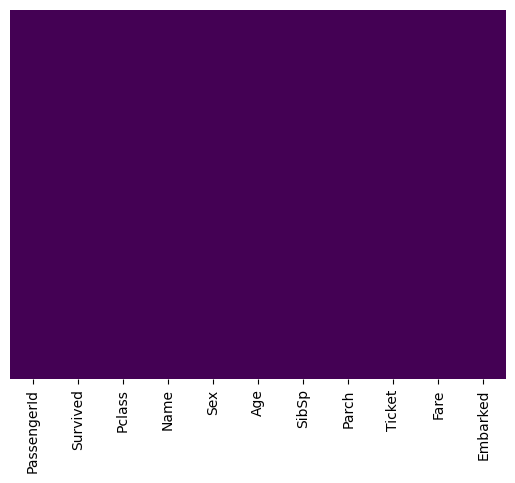

In [31]:
#用heatmap查看年齡是否還有缺失資料
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [32]:
#刪除所有含有缺失值（NaN）的資料列
#inplace=True，直接修改原本的Train
#若沒有加inplace=True，會產生新的DataFrame，但原本train不變
train.dropna(inplace=True)#inplace： False: 返回新的數據集（默認） True: 在原數據集上操作

In [36]:
#虛擬變數範例
#使用pandas(d.get_dummies)將性別從類別資料轉為數值變數。類別資料（Categorical Data）轉換成機器學習可使用的數值資料
sex = pd.get_dummies(train['Sex'],drop_first=True)
#請將drop_first=True，如果為True會刪除第一個類別值，只剩male，系統自動把female當作基準類別，避免dummy variable trap 
#本來若有k個level，drop_first=True會只剩下k-1個level，降低共線性的可能
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


In [37]:
#使用pandas將上船的港口從類別資料改換為數值變數(drop_first=True)
#都是使用 One-Hot Encoding（獨熱編碼） 將文字類別轉換成數值欄位
embark = pd.get_dummies(train['Embarked'],drop_first=True)
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [38]:
#將性別及上船港口的數值變數和原始的data結合
train = pd.concat([train,sex,embark],axis=1)
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


In [39]:
#將原始的性別、登船港口、票號、姓名欄位棄用
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [40]:
#因為PassengerId在此也只是排序，因此也棄用
train.drop('PassengerId',axis=1,inplace=True)
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [41]:
#建立feature資料集(選取survived以外所有欄位)與target資料集(survived)
#建立機器學習模型的X(特徵資料)、y(目標資料)
X = train.drop('Survived',axis=1) #drop Survived行，其他作為特徵值，來預測是否存活
y = train['Survived'] 

In [42]:
#載入訓練組及測試組分組套件
from sklearn.model_selection import train_test_split

In [43]:
#設定隨機種子(random_state)為101，測試組比例佔30%
#請用 101 當作亂數起點，因此每次執行都會得到相同的訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

In [44]:
#載入邏輯回歸
from sklearn.linear_model import LogisticRegression

In [45]:
#建立訓練組邏輯迴歸模型
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

C:\Users\pingy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
#使用模型進行測試集資料的預測
predictions = logmodel.predict(X_test)
predictions2 = logmodel.predict(X_train)

In [48]:
#ground truth
print(y_test.values)
print(y_train.values)

[0 1 0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0
 0 0 1 1 1 1 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0
 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 1 1
 1 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1
 0 0 1 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 1 1 1 0
 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1
 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 0 1
 0 0 1 1 0 1 1 0 1]
[1 1 1 1 1 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1
 0 0 1 1 0 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0
 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0
 0 1 1 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 1 1 0
 0 1 

#### 計算accuracy及結果顯示
accuracy<br>
error_index #錯誤答案是哪幾筆資料<br>
miss classification #錯誤答案<br>
錯誤欄位的正確之原始資料表格

In [51]:
error_index2=np.where(predictions2!=y_train.values)[0]
print('train accuracy:',1-len(error_index2)/len(X_train))
error_index=np.where(predictions!=y_test.values)[0]
print('test accuracy:',1-len(error_index)/len(X_test))

train accuracy: 0.8186195826645265
test accuracy: 0.7798507462686567


In [53]:
print('error_index:',error_index)
print('miss classification :',predictions[error_index])#錯誤答案
data_index=train.iloc[error_index].index#這裡變數train是所有資料
train.iloc[data_index]#錯誤欄位的正確之原始資料

error_index: [  2   3   6  13  14  33  39  45  55  56  63  67  70  71  74  82  86  89
  94  99 103 104 109 110 111 114 125 127 129 147 151 155 157 162 164 180
 181 184 192 195 197 198 200 201 205 206 208 210 220 221 230 231 232 235
 240 249 250 262 265]
miss classification : [1 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0
 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 0]
